In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [3]:
datas = pd.read_csv('./zkp_benchmark_results_64.csv')
print(datas)

   N_Voters  Depth  NM_Avg_Prove_s  NM_Avg_Verify_s  NM_RAM_MB  M_Avg_Prove_s  \
0         1      1          1.2438           0.7847       0.01         2.9699   
1         2      1          1.1029           0.7892       0.00         2.5105   
2         4      2          1.0784           0.8168       0.00         2.4697   
3         8      3          1.0361           0.7636       0.00         2.4913   
4        16      4          1.0337           0.7695       0.01         2.5061   
5        32      5          1.0432           0.7671       0.14         2.5641   
6        64      6          1.0503           0.7772       0.02         2.5668   
7       128      7          0.9910           0.7265       0.02         1.2087   

   M_Avg_Verify_s  M_RAM_MB  
0          0.7355      0.00  
1          0.8355      0.00  
2          0.7982      0.00  
3          0.7882      0.00  
4          0.7400      0.00  
5          0.7990      0.00  
6          0.7876      0.02  
7          0.7193      0.00  


In [16]:
systems = []
nm_avg_prove_time = list(datas['NM_Avg_Prove_s'])
nm_avg_verify_time = list(datas['NM_Avg_Verify_s'])
m_avg_prove_time = list(datas['M_Avg_Prove_s'])
m_avg_verify_time = list(datas['M_Avg_Verify_s'])
voters = list(datas['N_Voters'])

depth = list(datas['Depth'])

print(nm_avg_prove_time)
print(nm_avg_verify_time)
print(m_avg_prove_time)
print(m_avg_verify_time)
print(voters)
print(depth)

[1.2438, 1.1029, 1.0784, 1.0361, 1.0337, 1.0432, 1.0503, 0.991]
[0.7847, 0.7892, 0.8168, 0.7636, 0.7695, 0.7671, 0.7772, 0.7265]
[2.9699, 2.5105, 2.4697, 2.4913, 2.5061, 2.5641, 2.5668, 1.2087]
[0.7355, 0.8355, 0.7982, 0.7882, 0.74, 0.799, 0.7876, 0.7193]
[1, 2, 4, 8, 16, 32, 64, 128]
[1, 1, 2, 3, 4, 5, 6, 7]


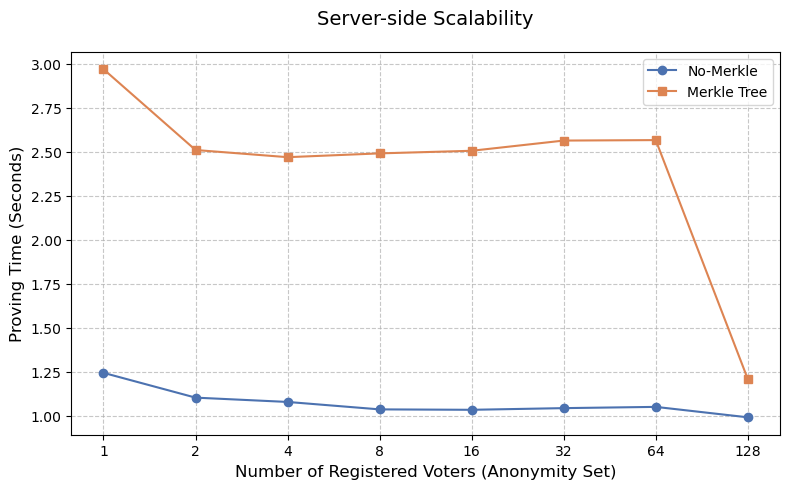

In [18]:
fig2, ax2 = plt.subplots(figsize=(8, 5))

# 建議同時畫出 No-Merkle 與 Merkle 的數據進行比較
ax2.plot(voters, nm_avg_prove_time, marker='o', label='No-Merkle', color='#4c72b0')
ax2.plot(voters, m_avg_prove_time, marker='s', label='Merkle Tree', color='#dd8452')

ax2.set_xlabel('Number of Registered Voters (Anonymity Set)', fontsize=12)
ax2.set_ylabel('Proving Time (Seconds)', fontsize=12)
ax2.set_title('Server-side Scalability', fontsize=14, pad=20)

# 使用對數尺度顯示 X 軸 (Voters)
ax2.set_xscale('log', base=2)
ax2.set_xticks(voters)
ax2.set_xticklabels(voters)

ax2.grid(True, linestyle='--', alpha=0.7)
ax2.legend() # 加入圖例

plt.tight_layout()
plt.savefig('scalability_analysis.png', dpi=300, bbox_inches='tight')
plt.show()